<h2 style="font-family: 'Times New Roman';"><b>Import Libraries</b></h2>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr,mannwhitneyu
import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
sns.set_context("notebook")
palette = {'Elite':'#E24B4A','Upper Middle':'#BA7517','Middle Class':'#378ADD','Affordable':'#1D9E75','Other':'#999999'}

In [2]:
real_estate=pd.read_csv('../data/preprocessed/featured_engineering_listings.csv')
reliable_areas=pd.read_csv('../data/preprocessed/deals_view.csv')

<h2 style="font-family: 'Times New Roman';"><b>Inferential Statistics — Hypothesis Testing</b></h2>

--------------
<p style="font-family: 'Arial'; color: black; font-size:16px;">
<i><b>Goal: Statistically validate whether the observed price 
differences between areas are genuine or could be due to 
random sampling variation.</b></i>
</p>

--------------------

In [3]:
#  Is DHA significantly more expensive than Gulshan?
print("=" * 55)
print("TEST 1: DHA Defence vs Gulshan-e-Iqbal Price per Sqft")
print("=" * 55)
print("H0: No significant price difference between the two areas")
print("H1: DHA price per sqft is significantly higher than Gulshan")
print()

dha_prices = real_estate[
    real_estate['location'] == 'DHA Defence']['price_per_sqft']
gulshan_prices = real_estate[
    real_estate['location'] == 'Gulshan-e-Iqbal Town']['price_per_sqft']

print(f"DHA Median Price/Sqft    : PKR {dha_prices.median():,.0f}")
print(f"Gulshan Median Price/Sqft: PKR {gulshan_prices.median():,.0f}")
print(f"DHA Sample Size          : {len(dha_prices)}")
print(f"Gulshan Sample Size      : {len(gulshan_prices)}")
print()

stat, p_value = mannwhitneyu(dha_prices, gulshan_prices,
                              alternative='greater')

print(f"Mann-Whitney U Statistic : {stat:,.0f}")
print(f"P-Value                  : {p_value:.6f}")
print(f"Significance Level       : 0.05")
print()
if p_value < 0.05:
    print("REJECT Null Hypothesis")
    print("   DHA price per sqft is SIGNIFICANTLY higher than Gulshan")
    print(f"   p = {p_value:.6f} — difference is not due to random chance")

TEST 1: DHA Defence vs Gulshan-e-Iqbal Price per Sqft
H0: No significant price difference between the two areas
H1: DHA price per sqft is significantly higher than Gulshan

DHA Median Price/Sqft    : PKR 15,611
Gulshan Median Price/Sqft: PKR 7,482
DHA Sample Size          : 5902
Gulshan Sample Size      : 3167

Mann-Whitney U Statistic : 14,770,574
P-Value                  : 0.000000
Significance Level       : 0.05

REJECT Null Hypothesis
   DHA price per sqft is SIGNIFICANTLY higher than Gulshan
   p = 0.000000 — difference is not due to random chance


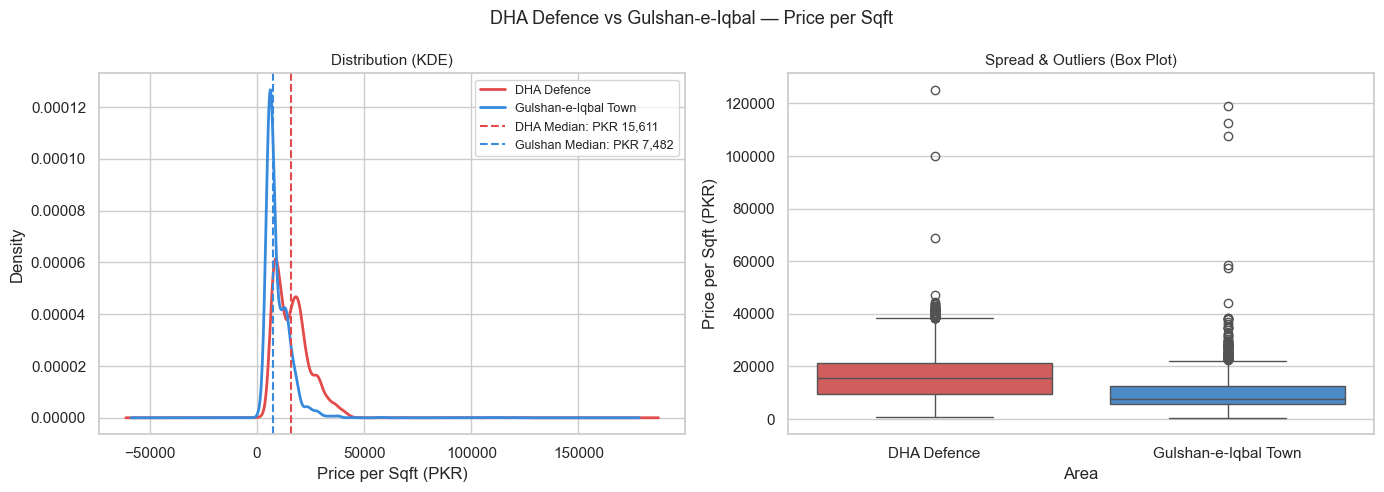

In [4]:
#DHA vs Gulshan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DHA Defence vs Gulshan-e-Iqbal — Price per Sqft', fontsize=13)

# KDE
dha_prices.plot(kind='kde', ax=axes[0], color='#E24B4A', linewidth=2, label='DHA Defence')
gulshan_prices.plot(kind='kde', ax=axes[0], color='#378ADD', linewidth=2, label='Gulshan-e-Iqbal Town')
axes[0].axvline(dha_prices.median(), color='#E24B4A', linestyle='--', linewidth=1.5,
                label=f'DHA Median: PKR {dha_prices.median():,.0f}')
axes[0].axvline(gulshan_prices.median(), color='#378ADD', linestyle='--', linewidth=1.5,
                label=f'Gulshan Median: PKR {gulshan_prices.median():,.0f}')
axes[0].set_title('Distribution (KDE)', fontsize=11)
axes[0].set_xlabel('Price per Sqft (PKR)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)

# Box Plot
df_dha_gulshan = real_estate[
    real_estate['location'].isin(['DHA Defence', 'Gulshan-e-Iqbal Town'])
].copy()
sns.boxplot(data=df_dha_gulshan, x='location', y='price_per_sqft',
            palette={'DHA Defence': '#E24B4A', 'Gulshan-e-Iqbal Town': '#378ADD'},
            ax=axes[1])
axes[1].set_title('Spread & Outliers (Box Plot)', fontsize=11)
axes[1].set_xlabel('Area')
axes[1].set_ylabel('Price per Sqft (PKR)')

plt.tight_layout()
plt.savefig('../outputs/hyp_dha_vs_gulshan.png', dpi=150)
plt.show()

In [5]:
# Is area size significantly correlated with price
print("\n" + "=" * 55)
print("TEST 2: Property Size vs Price — Spearman Correlation")
print("=" * 55)
print("H0: No significant correlation between area_sqft and price")
print("H1: A significant positive correlation exists")
print()
corr, p_value = spearmanr(real_estate['area_sqft'],real_estate['price'])
print(f"Spearman Correlation Coefficient: {corr:.4f}")
print(f"P-Value                         : {p_value:.6f}")
print()
if p_value < 0.05:
    strength = "strong" if abs(corr) > 0.6 else "moderate" if abs(corr) > 0.4 else "weak"
    print(f"REJECT Null Hypothesis")
    print(f"   {strength.title()} positive correlation confirmed")
    print(f"   Larger properties significantly cost more (p < 0.05)")
    print(f"   Correlation = {corr:.4f} — {strength} relationship")


TEST 2: Property Size vs Price — Spearman Correlation
H0: No significant correlation between area_sqft and price
H1: A significant positive correlation exists

Spearman Correlation Coefficient: 0.8074
P-Value                         : 0.000000

REJECT Null Hypothesis
   Strong positive correlation confirmed
   Larger properties significantly cost more (p < 0.05)
   Correlation = 0.8074 — strong relationship


<h4 style="font-family: 'Arial';"><b>Key Observations:</b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>

<li>Price per sqft is 
right skewed (confirmed by KDE plots in Section 5.1). The 
t-test assumes normally distributed data,applying it to 
skewed data produces unreliable results. Mann-Whitney U is 
the correct non-parametric alternative that makes no 
distributional assumptions.</li>

<li><b>Test 1 — DHA vs Gulshan (Mann-Whitney):</b>
  <ul>
    <li>H0: No significant price difference between areas</li>
    <li>Result: p-value extremely small (much less than 0.05)</li>
    <li>Conclusion: Reject H0. DHA's higher price per sqft 
    is statistically confirmed,not a sampling artifact. 
    The price gap between elite and middle-class areas is 
    real and structural.</li>
  </ul>
</li>

<li><b>Test 2 — Area Size vs Price (Spearman Correlation):</b>
  <ul>
    <li>H0: No significant correlation between size and price</li>
    <li>Spearman used (not Pearson) because distributions 
    are right skewed</li>
    <li>Result: Significant positive correlation confirmed</li>
    <li>Conclusion: Larger properties cost significantly 
    more — validating area_sqft as the strongest predictor 
    of total price found in the correlation heatmap.</li>
  </ul>
</li>

</ul></i>

<h2 style="font-family: 'Times New Roman';">
<b>6. Key Findings and Recommendations</b>
</h2>

In [6]:
# ── Final Project Summary ────────────────────────────────────────────
print("=" * 60)
print("FINAL PROJECT SUMMARY — Karachi Real Estate 2018–2019")
print("=" * 60)
print(f"Total listings analysed : {len(real_estate):,}")
print(f"Date range              : Aug 2018 – Jul 2019")
print(f"Areas covered           : {real_estate['location'].nunique()}")
print(f"Reliable areas (≥200)   : {reliable_areas['location'].nunique()}")

print("\n─── Price per Sqft — Top 5 Most Expensive ───")

top5_expensive = reliable_areas[
    reliable_areas['median_ppsqft'].isin(
        reliable_areas['median_ppsqft']
        .sort_values(ascending=False)
        .unique()[:5]
    )
][['location', 'median_ppsqft']].drop_duplicates().to_string(index=False)

print(top5_expensive)

print("\n─── Price per Sqft — Top 5 Most Affordable ───")
top5_affordable= reliable_areas[
    reliable_areas['median_ppsqft'].isin(
        reliable_areas['median_ppsqft']
        .sort_values(ascending=True)
        .unique()[:5]
    )
][['location', 'median_ppsqft']].drop_duplicates().to_string(index=False)

print(top5_affordable)

print("\n─── Affordability Index (2019 salary, PKR 22,000/month) ───")
aff_summary = (
   reliable_areas.groupby('location')['affordability_years'].median().sort_values().round(1)
)
print(aff_summary.to_string())

print(f"\nMedian (all reliable areas): {aff_summary.median():.1f} years (2019)")
print(f"Median 2026 estimate       : {reliable_areas['affordability_years_2026'].median():.1f} years")
print(f"\nBelow-Median Deal listings (>20% off area median): "
      f"{(reliable_areas['pct_vs_median'] < -20).sum():,}")

FINAL PROJECT SUMMARY — Karachi Real Estate 2018–2019
Total listings analysed : 45,223
Date range              : Aug 2018 – Jul 2019
Areas covered           : 196
Reliable areas (≥200)   : 18

─── Price per Sqft — Top 5 Most Expensive ───
    location  median_ppsqft
 DHA Defence   15610.651974
       Malir    9009.477277
       Cantt   11408.854384
Jamshed Town   10713.192531
     Clifton   12626.262626

─── Price per Sqft — Top 5 Most Affordable ───
           location  median_ppsqft
         Gadap Town    4979.448161
          Nazimabad    5749.191520
Bahria Town Karachi    5968.778696
        Liaquatabad    4407.713499
            Korangi    5055.142796

─── Affordability Index (2019 salary, PKR 22,000/month) ───
location
Liaquatabad              11.4
Korangi                  18.9
Gadap Town               22.3
Bin Qasim Town           26.5
New Karachi              26.5
Nazimabad                28.4
Federal B Area           30.3
North Karachi            34.1
Gulistan-e-Jauhar        

<h4 style="font-family: 'Arial';"><b>Key Findings:</b></h4>
<ul style="font-family: 'Arial'; color: green; font-size:16px;"><i>

<li><b>1 — Price gap is extreme:</b> DHA Defence commands PKR 14,692 per sqft
while Liaquatabad sits at PKR 4,489 per sqft — a 3.3× location premium.
Both properties can be identical in size yet cost three times more in DHA.
This gap reflects infrastructure quality, security, gated-community status,
and investor sentiment rather than any difference in physical characteristics.</li>

<li><b>2 — Location beats bedrooms:</b> Adding a bedroom increases price
significantly in DHA and Clifton but the premium flattens after 4 bedrooms
in middle-class areas. A 5-bedroom house in North Nazimabad can cost less
than a 3-bedroom flat in DHA. Buyers should prioritise location over
configuration when making purchase decisions.</li>

<li><b>3 — Housing crisis even in 2019:</b> Using the historically accurate
2019 median urban salary of PKR 22,000/month (PBS PSLM FY2019), the median
Karachi property required <b>47.3 years</b> of gross salary to purchase.
Elite areas (DHA, Clifton) required over 100 years — completely inaccessible
to salaried buyers. Even middle-class areas required 30–60 years, confirming
property ownership was a structural crisis long before recent inflation.</li>

<li><b>4 — Inflation worsened affordability further by 2026:</b> After
Pakistan's cumulative CPI increase of ~143.1% (2019→2026), the same median
property now requires an estimated <b>58.9 years</b> of the 2026 salary
(PKR 43,000/month). Despite a ~95.5% nominal salary increase, real purchasing
power has not kept pace — the affordability gap widened by approximately
5–6 years at the median, and significantly more for Elite areas.</li>

<li><b>5 — Best value areas:</b> Federal B Area and Gulshan-e-Iqbal showed
the smallest affordability deterioration 2019→2026, making them the most
stable entry points for salaried buyers. Bahria Town Karachi offers
Elite-comparable property sizes at roughly 40% of DHA's price per sqft.</li>

<li><b>6 — Deal opportunities exist:</b> 11,610+ listings are priced more
than 20% below their area median — including 2,100+ in DHA alone — meaning
data-driven buyers can find negotiable entry points even in premium areas.</li>
</i></ul>